# Soch Machine Learning Models

This notebook documents the machine-learning pipeline for the **Soch** project. It uses the shared Python modules to keep data cleaning, feature encoding, target engineering, training, evaluation, and export logic consistent with the frontend artifact flow.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_raw_dataset
from src.export_artifacts import create_artifacts
from src.ml_models import train_models
from src.preprocessing import (
    ADDICTION_SCORE_COMPONENTS,
    MODEL_FEATURE_SPECS,
    prepare_survey_dataset,
    serialize_preprocessing_config,
)
from src.stats_analysis import (
    build_frequency_table,
    clt_simulation,
    descriptive_statistics,
    histogram_frame,
    probability_summary,
    random_variable_summary,
)

sns.set_theme(style="whitegrid", palette="crest")
load_result = load_raw_dataset()
prepared = prepare_survey_dataset(load_result)
cleaned_df = prepared.cleaned_df.copy()
model_df = prepared.model_df.copy()
model_results = train_models(prepared)
preprocessing_config = serialize_preprocessing_config(prepared)

## 1. ML Notebook Introduction

**Concept**  
The goal is to train two interpretable models:

1. Linear Regression for continuous Addiction Score prediction
2. Logistic Regression for binary addiction-risk prediction

The pipeline is designed for browser deployment through exported JSON artifacts.

## 2. Feature Engineering

**Concept**  
Only the strongest, frontend-available features are used in the models. Their order must stay fixed so Python and TypeScript produce the same predictions.

**Formula**  
Feature vector:

\[
X = [x_1, x_2, \dots, x_8]
\]

In [2]:
feature_table = pd.DataFrame(
    [
        {
            "frontend_key": spec.frontend_key,
            "python_key": spec.key,
            "label": spec.label,
            "allowed_codes": spec.options,
            "default_code": prepared.feature_defaults[spec.key],
        }
        for spec in MODEL_FEATURE_SPECS
    ]
)
display(feature_table)

,frontend_key,python_key,label,allowed_codes,default_code
0,dailyHours,daily_hours,Daily phone usage,"((1, Less than 2 hours), (2, 2-4 hours), (3, 4...",3
1,checkingFrequency,checking_frequency,Checking frequency,"((1, Less than 10 times), (2, 10-30 times), (3...",2
2,beforeSleep,before_sleep,Before-sleep use,"((1, Sometimes), (2, Often), (3, Every day))",3
3,anxiousWithoutPhone,anxious_without_phone,Anxiety without phone,"((0, No), (1, Sometimes), (2, Yes))",1
4,studyDistraction,study_distraction,Study distraction,"((1, Never), (2, Sometimes), (3, Often), (4, A...",3
5,wasteTime,waste_time,Feels like wasted time,"((0, No), (1, Sometimes), (2, Yes))",1
6,socialMediaIntensity,social_media_intensity,Social media intensity,"((1, Strongly Disagree), (2, Disagree), (3, Ne...",4
7,reductionIntent,reduction_intent,Reduction intent,"((1, Strongly Disagree), (2, Disagree), (3, Ne...",4


## 3. Target Engineering

**Concept**  
The target is not taken from a black-box label. It is built from documented behavioral components and a transparent threshold rule.

**Formula**  
Weighted Addiction Score:

\[
\text{Score} = \frac{\sum w_i s_i}{\sum w_i} \times 100
\]

Binary risk label:

\[
Y =
\begin{cases}
1 & \text{if score} \ge 60 \\
1 & \text{if score} \ge 55 \text{ and self-report is Yes/Maybe} \\
0 & \text{otherwise}
\end{cases}
\]

In [3]:
component_table = pd.DataFrame(
    [
        {
            "feature_key": component.feature_key,
            "label": next(spec.label for spec in MODEL_FEATURE_SPECS if spec.key == component.feature_key)
            if component.feature_key in {spec.key for spec in MODEL_FEATURE_SPECS}
            else component.feature_key,
            "weight": component.weight,
            "rationale": component.rationale,
        }
        for component in ADDICTION_SCORE_COMPONENTS
    ]
)
display(component_table)
display(model_df[["response_id", "addiction_score", "risk_binary", "risk_label"]].head())

,feature_key,label,weight,rationale
0,daily_hours,Daily phone usage,0.18,Long daily usage increases compulsive exposure...
1,checking_frequency,Checking frequency,0.14,Frequent checking is a strong behavioral marke...
2,before_sleep,Before-sleep use,0.10,Night-time use is linked to habit reinforcemen...
3,wake_check,wake_check,0.07,Immediate morning checking signals routine-dri...
4,anxious_without_phone,Anxiety without phone,0.10,Anxiety without the phone reflects emotional a...
5,study_distraction,Study distraction,0.12,Distraction during study indicates direct inte...
6,class_usage,class_usage,0.07,Using the phone during class signals poor cont...
7,sleep_affected,sleep_affected,0.08,Sleep impact is a meaningful downstream conseq...
8,waste_time,Feels like wasted time,0.07,Perceived time wastage captures self-awareness...
9,battery_low,battery_low,0.03,Discomfort when the battery is low reflects at...


,response_id,addiction_score,risk_binary,risk_label
0,R001,80.1,1,Elevated addiction risk
1,R002,75.5,1,Elevated addiction risk
2,R003,70.5,1,Elevated addiction risk
3,R004,43.7,0,Lower addiction risk
4,R005,7.0,0,Lower addiction risk


## 4. Train/Test Split

**Concept**  
Evaluation uses a fixed random seed and a hold-out test split so the reported metrics are teacher-checkable and reproducible.

In [4]:
display(pd.Series(model_results["split"]).to_frame(name="value"))

,value
random_state,42
train_response_ids,"[R013, R004, R030, R016, R024, R047, R034, R01..."
test_response_ids,"[R021, R001, R025, R020, R035, R051, R048, R03..."


## 5. Linear Regression Model

**Concept**  
Linear regression estimates how much each feature changes the predicted Addiction Score while keeping the other features fixed.

In [5]:
linear_summary = pd.Series(model_results["linear"]["metrics"])
linear_coefficients = pd.DataFrame(model_results["linear"]["coefficient_items"])
display(linear_summary.to_frame(name="value"))
display(linear_coefficients)

linear_predictions = pd.DataFrame(model_results["linear"]["test_predictions"])
display(linear_predictions.head())

,value
sample_size,51.000000
train_size,38.000000
test_size,13.000000
intercept,-21.699244
r2,0.923715
mae,4.129756
rmse,4.840917


,key,python_key,label,value
0,dailyHours,daily_hours,Daily phone usage,5.489640
1,checkingFrequency,checking_frequency,Checking frequency,5.359185
2,beforeSleep,before_sleep,Before-sleep use,5.686827
3,anxiousWithoutPhone,anxious_without_phone,Anxiety without phone,5.531434
4,studyDistraction,study_distraction,Study distraction,5.553173
5,wasteTime,waste_time,Feels like wasted time,3.933878
6,socialMediaIntensity,social_media_intensity,Social media intensity,0.975851
7,reductionIntent,reduction_intent,Reduction intent,2.148836


,response_id,actual_score,predicted_score
0,R021,51.7,53.793399
1,R001,80.1,83.158693
2,R025,42.1,44.869182
3,R020,50.7,61.293573
4,R035,53.8,59.123054


## 6. Logistic Regression Model

**Concept**  
Logistic regression estimates the probability of elevated addiction risk from the same fixed-order feature set.

In [6]:
logistic_summary = pd.Series(model_results["logistic"]["metrics"])
logistic_coefficients = pd.DataFrame(model_results["logistic"]["coefficient_items"])
display(logistic_summary.to_frame(name="value"))
display(logistic_coefficients)

logistic_predictions = pd.DataFrame(model_results["logistic"]["test_predictions"])
display(logistic_predictions.head())

,value
sample_size,51
train_size,38
test_size,13
accuracy,0.769231
precision,0.777778
recall,0.875
f1,0.823529
roc_auc,0.925
confusion_matrix,"[[3, 2], [1, 7]]"
intercept,-15.155123


,key,python_key,label,value
0,dailyHours,daily_hours,Daily phone usage,0.835378
1,checkingFrequency,checking_frequency,Checking frequency,0.605863
2,beforeSleep,before_sleep,Before-sleep use,1.415360
3,anxiousWithoutPhone,anxious_without_phone,Anxiety without phone,1.222479
4,studyDistraction,study_distraction,Study distraction,0.582890
5,wasteTime,waste_time,Feels like wasted time,0.353576
6,socialMediaIntensity,social_media_intensity,Social media intensity,0.304760
7,reductionIntent,reduction_intent,Reduction intent,0.956338


,response_id,actual_class,predicted_probability,predicted_class
0,R021,0,0.361062,0
1,R001,1,0.989015,1
2,R025,0,0.044846,0
3,R020,0,0.299920,0
4,R035,0,0.877428,1


## 7. Model Evaluation

**Concept**  
Model evaluation compares predicted values to actual held-out values using standard regression and classification metrics.

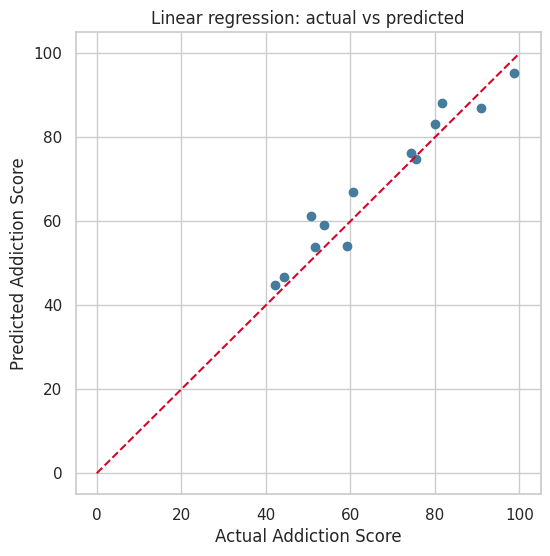

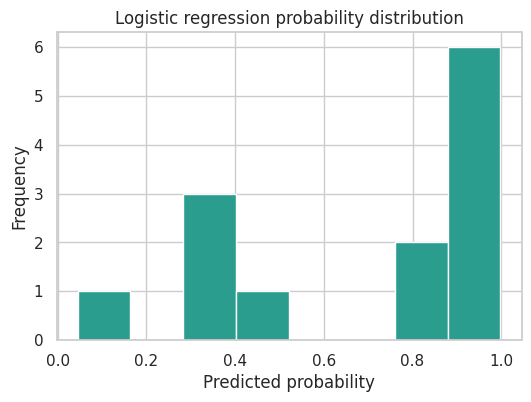

In [7]:
linear_predictions = pd.DataFrame(model_results["linear"]["test_predictions"])

plt.figure(figsize=(6, 6))
plt.scatter(linear_predictions["actual_score"], linear_predictions["predicted_score"], color="#457b9d")
plt.plot([0, 100], [0, 100], linestyle="--", color="#d90429")
plt.xlabel("Actual Addiction Score")
plt.ylabel("Predicted Addiction Score")
plt.title("Linear regression: actual vs predicted")
plt.show()

if not logistic_predictions.empty:
    logistic_predictions = pd.DataFrame(model_results["logistic"]["test_predictions"])
    plt.figure(figsize=(6, 4))
    plt.hist(logistic_predictions["predicted_probability"], bins=8, color="#2a9d8f", edgecolor="white")
    plt.xlabel("Predicted probability")
    plt.ylabel("Frequency")
    plt.title("Logistic regression probability distribution")
    plt.show()

## 8. Model Interpretation

**Concept**  
Positive coefficients push the score or probability upward. Negative coefficients pull the prediction downward.

In [8]:
display(
    linear_coefficients.assign(direction=linear_coefficients["value"].map(lambda value: "Positive" if value >= 0 else "Negative"))
    .sort_values("value", ascending=False)
)

display(
    logistic_coefficients.assign(direction=logistic_coefficients["value"].map(lambda value: "Positive" if value >= 0 else "Negative"))
    .sort_values("value", ascending=False)
)

,key,python_key,label,value,direction
2,beforeSleep,before_sleep,Before-sleep use,5.686827,Positive
4,studyDistraction,study_distraction,Study distraction,5.553173,Positive
3,anxiousWithoutPhone,anxious_without_phone,Anxiety without phone,5.531434,Positive
0,dailyHours,daily_hours,Daily phone usage,5.489640,Positive
1,checkingFrequency,checking_frequency,Checking frequency,5.359185,Positive
5,wasteTime,waste_time,Feels like wasted time,3.933878,Positive
7,reductionIntent,reduction_intent,Reduction intent,2.148836,Positive
6,socialMediaIntensity,social_media_intensity,Social media intensity,0.975851,Positive


,key,python_key,label,value,direction
2,beforeSleep,before_sleep,Before-sleep use,1.415360,Positive
3,anxiousWithoutPhone,anxious_without_phone,Anxiety without phone,1.222479,Positive
7,reductionIntent,reduction_intent,Reduction intent,0.956338,Positive
0,dailyHours,daily_hours,Daily phone usage,0.835378,Positive
1,checkingFrequency,checking_frequency,Checking frequency,0.605863,Positive
4,studyDistraction,study_distraction,Study distraction,0.582890,Positive
5,wasteTime,waste_time,Feels like wasted time,0.353576,Positive
6,socialMediaIntensity,social_media_intensity,Social media intensity,0.304760,Positive


## 9. Sample Prediction Examples

**Concept**  
Sample cases help verify that Python inference and frontend inference stay aligned.

In [9]:
export_results = create_artifacts()
validation_cases = pd.DataFrame(export_results["model_artifacts"]["validation_cases"])
display(validation_cases[["case_id", "label", "input", "expected"]].head())

,case_id,label,input,expected
0,dataset_default,Dataset default,"{'dailyHours': 3, 'checkingFrequency': 2, 'bef...","{'addiction_score': 61.172106, 'addiction_prob..."
1,balanced_student,Balanced student,"{'dailyHours': 2, 'checkingFrequency': 2, 'bef...","{'addiction_score': 37.779788, 'addiction_prob..."
2,heavy_scroll,Heavy scroll,"{'dailyHours': 4, 'checkingFrequency': 4, 'bef...","{'addiction_score': 95.523288, 'addiction_prob..."
3,study_mode,Study mode,"{'dailyHours': 1, 'checkingFrequency': 1, 'bef...","{'addiction_score': 10.936627, 'addiction_prob..."
4,night_habit,Night habit,"{'dailyHours': 3, 'checkingFrequency': 3, 'bef...","{'addiction_score': 70.465169, 'addiction_prob..."


## 10. Artifact Export for Frontend

**Concept**  
The exported JSON files contain the trained parameters, fixed feature order, preprocessing defaults, validation cases, and label mappings needed for in-browser inference.

In [10]:
artifact_overview = pd.Series(
    {
        "Model artifact": "artifacts/model_artifacts.json",
        "Preprocessing artifact": "artifacts/preprocessing_config.json",
        "Cleaned dataset": "artifacts/cleaned_dataset.csv",
    }
)
display(artifact_overview.to_frame(name="path"))

,path
Model artifact,artifacts/model_artifacts.json
Preprocessing artifact,artifacts/preprocessing_config.json
Cleaned dataset,artifacts/cleaned_dataset.csv


## 11. Final ML Conclusion

**Interpretation**  
The Soch ML layer is intentionally interpretable: the targets are transparent, the models are standard scikit-learn regressions, the preprocessing rules are centralized, and the frontend can run the final predictors without a backend.

In [11]:
for line in [
    f"Model rows available for training: {prepared.metadata['model_row_count']}",
    f"Linear regression R^2: {model_results['linear']['metrics']['r2']:.3f}",
    f"Logistic regression accuracy: {model_results['logistic']['metrics']['accuracy']:.3f}",
    "Artifacts were exported for browser inference with validation cases embedded.",
]:
    print("-", line)

- Model rows available for training: 51
- Linear regression R^2: 0.924
- Logistic regression accuracy: 0.769
- Artifacts were exported for browser inference with validation cases embedded.
